CHẨN ĐOÁN C5 (công bằng vùng miền) trước khi giải
• Vùng nền cao nhất: SE với D0=82  -> buộc Dmax M >= 82
• Vùng yếu nhất    : CH với D0=32, dồn hết 12000 vào D -> D tối đa = 56.0
• Để thỏa C5 dưới: 0.7*M <= 56.0 -> M <= 80.00
• MÂU THUẪN: cần M>=82 nhưng M<=80.00 => MÔ HÌNH BẤT KHẢ THI với λ=0.70
• λ khả thi lớn nhất ≈ 0.6829. Ta dùng λ = 0.68 (an toàn dưới ngưỡng) cho phần còn lại.

CÂU 4.4.1 — Giải bằng PuLP / CBC (mô hình có C5, λ=0.68)
Trạng thái CBC: Optimal   (LUÔN kiểm tra status, không chỉ đọc objective!)
>>> Z* (PuLP) = 54,192.00 tỷ VND GDP gain

Ma trận phân bổ tối ưu x[vùng, hạng mục]  (đơn vị: tỷ VND):
                       Hạ tầng (I)  Số hóa (D)  Trí tuệ NT (AI)  Nhân lực (H)  TỔNG vùng
Trung du-Miền núi Bắc          0.0     8,880.0              0.0       3,120.0   12,000.0
ĐB sông Hồng                   0.0         0.0          5,000.0           0.0    5,000.0
Bắc Trung Bộ-DH Trung          0.0       380.0              0.0       4,620.0    5,000.0
Tây Nguyên           

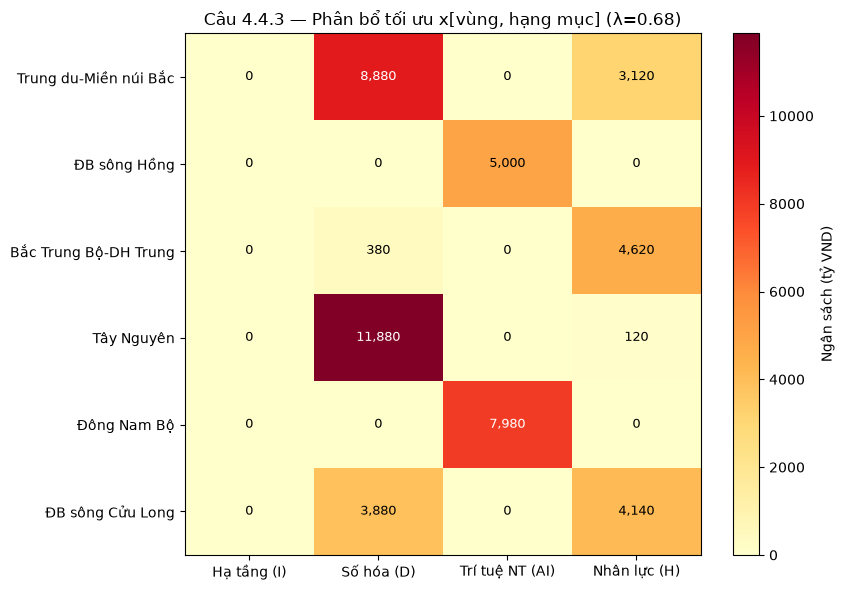

Vùng nhận NHIỀU ngân sách nhất: Trung du-Miền núi Bắc (12,000 tỷ VND).

Hạng mục ưu tiên (nhận nhiều nhất) ở từng vùng:
  • Trung du-Miền núi Bắc       : Số hóa (D) (8,880 tỷ)
  • ĐB sông Hồng                : Trí tuệ NT (AI) (5,000 tỷ)
  • Bắc Trung Bộ-DH Trung       : Nhân lực (H) (4,620 tỷ)
  • Tây Nguyên                  : Số hóa (D) (11,880 tỷ)
  • Đông Nam Bộ                 : Trí tuệ NT (AI) (7,980 tỷ)
  • ĐB sông Cửu Long            : Nhân lực (H) (4,140 tỷ)

CÂU 4.4.4 — Đối chiếu mô hình KHÔNG có ràng buộc công bằng (bỏ C5)
Trạng thái: Optimal
>>> Z* KHÔNG công bằng = 68,750.00 tỷ VND
>>> Z* CÓ công bằng    = 54,192.00 tỷ VND  (λ=0.68)

>>> CHI PHÍ KINH TẾ CỦA CÔNG BẰNG = 14,558.00 tỷ VND GDP gain
    (tương đương 21.18% tổng lợi ích tối đa).

                 Vùng  Tổng (có C5)  Tổng (bỏ C5)  Chênh lệch
Trung du-Miền núi Bắc      12,000.0       5,000.0     7,000.0
         ĐB sông Hồng       5,000.0      12,000.0    -7,000.0
Bắc Trung Bộ-DH Trung       5,000.0       5,000.0  

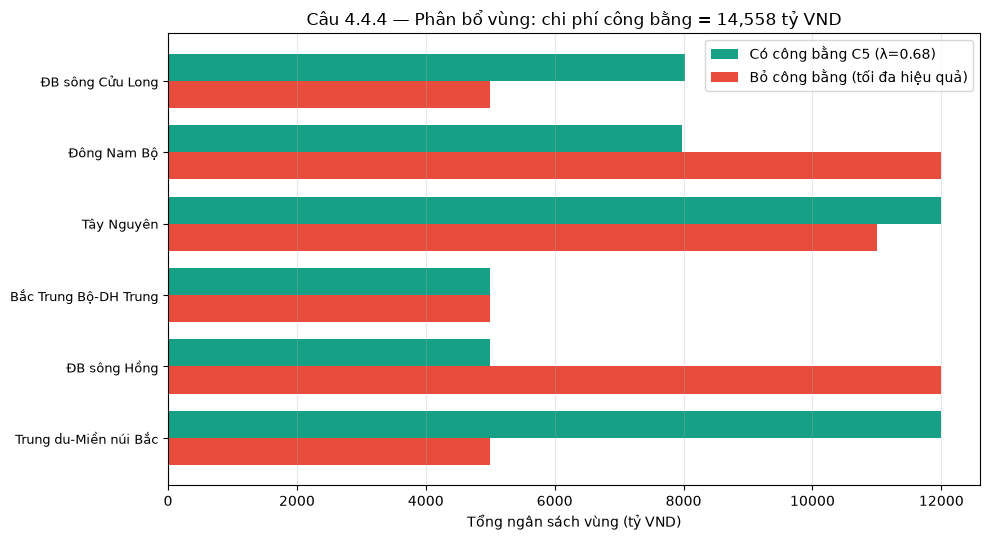


NHẬN XÉT CHÍNH SÁCH (4.4.4):
  • Khi BỎ C5, ngân sách dồn về các vùng/hạng mục có hệ số sinh lời β cao
    (AI ở SE/RRD, nhân lực H ở CH/NMM...) -> Z* đạt mức tối đa thuần hiệu quả.
  • Khi ÁP C5, phải san sẻ vốn cho vùng số hóa thấp để thu hẹp khoảng cách
    -> Z* giảm. Phần giảm 14,558 tỷ VND chính là "cái giá" đánh đổi
    để đạt công bằng vùng miền — khái niệm equity-efficiency tradeoff.
  • Lưu ý quan trọng: với λ=0.70 như đề, mô hình BẤT KHẢ THI; ngưỡng công bằng
    khả thi lớn nhất là λ≈0.683. Đây là thông tin chính sách then chốt:
    mục tiêu "vùng yếu nhất đạt ≥70% vùng mạnh nhất" là BẤT KHẢ THI với
    trần ngân sách và hệ số γ hiện hành — muốn đạt 70% phải tăng trần vùng,
    tăng γ (hiệu suất đầu tư số hóa), hoặc nâng tổng ngân sách.

HOÀN TẤT BÀI 4 (Câu 4.4.1 -> 4.4.4)


In [1]:
# =====================================================================
# BÀI 4 - PHÂN BỔ NGÂN SÁCH SỐ HÓA THEO VÙNG MIỀN (LP, 6 vùng × 4 hạng mục)
# Giải trọn vẹn Câu 4.4.1 -> 4.4.4 trong MỘT cell (Google Colab)
# QUAN TRỌNG: Mô hình gốc (λ=0.7) BẤT KHẢ THI - xem chẩn đoán bên dưới.
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cài solver nếu thiếu
try:
    import pulp
except ImportError:
    import subprocess, sys; subprocess.run([sys.executable,"-m","pip","install","-q","pulp"]); import pulp
try:
    import cvxpy as cp
except ImportError:
    import subprocess, sys; subprocess.run([sys.executable,"-m","pip","install","-q","cvxpy"]); import cvxpy as cp

# ---------------------------------------------------------------------
# DỮ LIỆU MÔ HÌNH
# ---------------------------------------------------------------------
regions = ['NMM', 'RRD', 'NCC', 'CH', 'SE', 'MD']   # 6 vùng kinh tế
items   = ['I', 'D', 'AI', 'H']                     # 4 hạng mục đầu tư
region_vi = {'NMM':'Trung du-Miền núi Bắc','RRD':'ĐB sông Hồng','NCC':'Bắc Trung Bộ-DH Trung',
             'CH':'Tây Nguyên','SE':'Đông Nam Bộ','MD':'ĐB sông Cửu Long'}
item_vi   = {'I':'Hạ tầng (I)','D':'Số hóa (D)','AI':'Trí tuệ NT (AI)','H':'Nhân lực (H)'}

beta = {('NMM','I'):1.15,('NMM','D'):0.85,('NMM','AI'):0.55,('NMM','H'):1.30,
        ('RRD','I'):0.95,('RRD','D'):1.25,('RRD','AI'):1.40,('RRD','H'):1.05,
        ('NCC','I'):1.05,('NCC','D'):0.95,('NCC','AI'):0.85,('NCC','H'):1.15,
        ('CH','I') :1.20,('CH','D') :0.75,('CH','AI') :0.45,('CH','H') :1.35,
        ('SE','I') :0.90,('SE','D') :1.30,('SE','AI') :1.55,('SE','H') :1.00,
        ('MD','I') :1.10,('MD','D') :0.85,('MD','AI') :0.65,('MD','H') :1.25}
D0    = {'NMM':38,'RRD':78,'NCC':55,'CH':32,'SE':82,'MD':48}   # mức số hóa nền (%)
gamma = 0.002          # hệ số chuyển ngân sách D -> điểm số hóa
LAM_REQ = 0.70         # λ yêu cầu trong đề
BUDGET, R_MIN, R_MAX, H_MIN = 50000, 5000, 12000, 12000

B_mat = np.array([[beta[(r,j)] for j in items] for r in regions])   # ma trận 6×4 hệ số

# =====================================================================
# CHẨN ĐOÁN TÍNH KHẢ THI CỦA RÀNG BUỘC CÔNG BẰNG C5 (λ=0.7)
# =====================================================================
print("="*78)
print("CHẨN ĐOÁN C5 (công bằng vùng miền) trước khi giải")
print("="*78)
D_floor_max = max(D0.values())                       # ép M >= mức nền cao nhất
worst = min(D0, key=D0.get)
D_ceil_worst = D0[worst] + gamma*R_MAX               # mức D tối đa vùng yếu nhất đạt được
lam_max = D_ceil_worst / D_floor_max                 # λ khả thi lớn nhất
print(f"• Vùng nền cao nhất: SE với D0=82  -> buộc Dmax M >= 82")
print(f"• Vùng yếu nhất    : {worst} với D0={D0[worst]}, dồn hết {R_MAX} vào D "
      f"-> D tối đa = {D_ceil_worst:.1f}")
print(f"• Để thỏa C5 dưới: 0.7*M <= {D_ceil_worst:.1f} -> M <= {D_ceil_worst/LAM_REQ:.2f}")
print(f"• MÂU THUẪN: cần M>=82 nhưng M<={D_ceil_worst/LAM_REQ:.2f} "
      f"=> MÔ HÌNH BẤT KHẢ THI với λ=0.70")
print(f"• λ khả thi lớn nhất ≈ {lam_max:.4f}. "
      f"Ta dùng λ = 0.68 (an toàn dưới ngưỡng) cho phần còn lại.\n")

LAM = 0.68   # giá trị khả thi dùng cho mô hình "có công bằng"

# ---------------------------------------------------------------------
# HÀM GIẢI PULP (dùng chung; fair=True bật C5 với λ cho trước)
# ---------------------------------------------------------------------
def solve_pulp(lam, fair=True):
    m = pulp.LpProblem('VN_Digital_Budget', pulp.LpMaximize)
    x = pulp.LpVariable.dicts('x', (regions, items), lowBound=0)
    m += pulp.lpSum(beta[(r,j)]*x[r][j] for r in regions for j in items)          # mục tiêu
    m += pulp.lpSum(x[r][j] for r in regions for j in items) <= BUDGET            # C1 tổng NS
    for r in regions:
        m += pulp.lpSum(x[r][j] for j in items) >= R_MIN                          # C2 sàn vùng
        m += pulp.lpSum(x[r][j] for j in items) <= R_MAX                          # C3 trần vùng
    m += pulp.lpSum(x[r]['H'] for r in regions) >= H_MIN                          # C4 sàn nhân lực
    if fair:
        Mv = pulp.LpVariable('Dmax', lowBound=0)
        for r in regions: m += D0[r] + gamma*x[r]['D'] <= Mv                      # C5a
        for r in regions: m += D0[r] + gamma*x[r]['D'] >= lam*Mv                  # C5b
    m.solve(pulp.PULP_CBC_CMD(msg=0))
    status = pulp.LpStatus[m.status]
    if status != 'Optimal':
        return status, None, None
    X = np.array([[x[r][j].value() for j in items] for r in regions])
    return status, pulp.value(m.objective), X

# =====================================================================
# CÂU 4.4.1 — GIẢI BẰNG PULP (CBC), IN MA TRẬN 6×4 VÀ Z*
# =====================================================================
print("="*78)
print(f"CÂU 4.4.1 — Giải bằng PuLP / CBC (mô hình có C5, λ={LAM})")
print("="*78)

status_p, Z_pulp, X_pulp = solve_pulp(LAM, fair=True)
print(f"Trạng thái CBC: {status_p}   (LUÔN kiểm tra status, không chỉ đọc objective!)")
print(f">>> Z* (PuLP) = {Z_pulp:,.2f} tỷ VND GDP gain\n")

X_df = pd.DataFrame(X_pulp, index=[region_vi[r] for r in regions],
                    columns=[item_vi[j] for j in items])
X_df['TỔNG vùng'] = X_df.sum(axis=1)
pd.options.display.float_format = '{:,.1f}'.format
print("Ma trận phân bổ tối ưu x[vùng, hạng mục]  (đơn vị: tỷ VND):")
print(X_df.to_string())
print(f"\nTổng ngân sách sử dụng = {X_pulp.sum():,.1f} / {BUDGET}")

# =====================================================================
# CÂU 4.4.2 — GIẢI LẠI BẰNG CVXPY, SO SÁNH VỚI PULP
# =====================================================================
print("\n" + "="*78)
print(f"CÂU 4.4.2 — Giải bằng CVXPY và so sánh với PuLP (λ={LAM})")
print("="*78)

X = cp.Variable((6, 4), nonneg=True)
cons = [cp.sum(X) <= BUDGET, cp.sum(X[:, items.index('H')]) >= H_MIN]
for i in range(6):
    cons += [cp.sum(X[i, :]) >= R_MIN, cp.sum(X[i, :]) <= R_MAX]
Mv = cp.Variable(nonneg=True)
d0 = np.array([D0[r] for r in regions])
for i in range(6):
    cons += [d0[i] + gamma*X[i, items.index('D')] <= Mv,
             d0[i] + gamma*X[i, items.index('D')] >= LAM*Mv]
prob = cp.Problem(cp.Maximize(cp.sum(cp.multiply(B_mat, X))), cons)
prob.solve(solver=cp.HIGHS)
Z_cvx, X_cvx = prob.value, X.value

print(f"Trạng thái CVXPY: {prob.status}")
print(f">>> Z* (CVXPY) = {Z_cvx:,.2f}   |   Z* (PuLP) = {Z_pulp:,.2f}")
print(f"Chênh lệch |Z*|        = {abs(Z_cvx - Z_pulp):.6f}")
print(f"Chênh lệch lớn nhất |x| = {np.abs(X_cvx - X_pulp).max():.6f}")
same = abs(Z_cvx - Z_pulp) < 1e-3 and np.abs(X_cvx - X_pulp).max() < 1e-2
print(f"\n>>> Hai phương pháp cho kết quả {'GIỐNG NHAU' if same else 'KHÁC NHAU'}.")
print("    (Cùng là bài toán LP lồi -> nghiệm tối ưu toàn cục duy nhất về giá trị Z*;")
print("     PuLP dùng CBC, CVXPY dùng HiGHS, cả hai hội tụ về cùng một optimum.)")

# =====================================================================
# CÂU 4.4.3 — HEATMAP PHÂN BỔ TỐI ƯU
# =====================================================================
print("\n" + "="*78)
print("CÂU 4.4.3 — Heatmap phân bổ tối ưu")
print("="*78)

fig, ax = plt.subplots(figsize=(8.5, 6))
im = ax.imshow(X_pulp, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(4)); ax.set_xticklabels([item_vi[j] for j in items], fontsize=10)
ax.set_yticks(range(6)); ax.set_yticklabels([region_vi[r] for r in regions], fontsize=10)
for i in range(6):
    for j in range(4):
        ax.text(j, i, f'{X_pulp[i,j]:,.0f}', ha='center', va='center',
                color='black' if X_pulp[i,j] < X_pulp.max()*0.6 else 'white', fontsize=9)
plt.colorbar(im, ax=ax, label='Ngân sách (tỷ VND)')
ax.set_title(f'Câu 4.4.3 — Phân bổ tối ưu x[vùng, hạng mục] (λ={LAM})', fontsize=12)
plt.tight_layout(); plt.show()

# Phân tích vùng nhận nhiều nhất & hạng mục ưu tiên từng vùng
region_tot = X_pulp.sum(axis=1)
top_region = regions[int(region_tot.argmax())]
print(f"Vùng nhận NHIỀU ngân sách nhất: {region_vi[top_region]} "
      f"({region_tot.max():,.0f} tỷ VND).")
print("\nHạng mục ưu tiên (nhận nhiều nhất) ở từng vùng:")
for i, r in enumerate(regions):
    j = int(X_pulp[i].argmax())
    print(f"  • {region_vi[r]:28s}: {item_vi[items[j]]} "
          f"({X_pulp[i,j]:,.0f} tỷ)")

# =====================================================================
# CÂU 4.4.4 — CHI PHÍ KINH TẾ CỦA CÔNG BẰNG VÙNG MIỀN (BỎ C5)
# =====================================================================
print("\n" + "="*78)
print("CÂU 4.4.4 — Đối chiếu mô hình KHÔNG có ràng buộc công bằng (bỏ C5)")
print("="*78)

status_nf, Z_nofair, X_nofair = solve_pulp(LAM, fair=False)
print(f"Trạng thái: {status_nf}")
print(f">>> Z* KHÔNG công bằng = {Z_nofair:,.2f} tỷ VND")
print(f">>> Z* CÓ công bằng    = {Z_pulp:,.2f} tỷ VND  (λ={LAM})")

cost_fair = Z_nofair - Z_pulp
print(f"\n>>> CHI PHÍ KINH TẾ CỦA CÔNG BẰNG = {cost_fair:,.2f} tỷ VND GDP gain")
print(f"    (tương đương {cost_fair/Z_nofair*100:.2f}% tổng lợi ích tối đa).")

# So sánh phân bổ tổng theo vùng: có vs không công bằng
tot_fair   = X_pulp.sum(axis=1)
tot_nofair = X_nofair.sum(axis=1)
cmp = pd.DataFrame({
    'Vùng': [region_vi[r] for r in regions],
    'Tổng (có C5)':   tot_fair.round(0),
    'Tổng (bỏ C5)':   tot_nofair.round(0),
    'Chênh lệch':     (tot_fair - tot_nofair).round(0),
})
print("\n" + cmp.to_string(index=False))

# Biểu đồ cột so sánh
ypos = np.arange(6); h = 0.38
plt.figure(figsize=(10, 5.5))
plt.barh(ypos + h/2, tot_fair,   h, label=f'Có công bằng C5 (λ={LAM})', color='#16a085')
plt.barh(ypos - h/2, tot_nofair, h, label='Bỏ công bằng (tối đa hiệu quả)', color='#e74c3c')
plt.yticks(ypos, [region_vi[r] for r in regions], fontsize=9)
plt.xlabel('Tổng ngân sách vùng (tỷ VND)')
plt.title(f'Câu 4.4.4 — Phân bổ vùng: chi phí công bằng = {cost_fair:,.0f} tỷ VND', fontsize=12)
plt.legend(); plt.grid(axis='x', alpha=0.3); plt.tight_layout(); plt.show()

print(f"""
NHẬN XÉT CHÍNH SÁCH (4.4.4):
  • Khi BỎ C5, ngân sách dồn về các vùng/hạng mục có hệ số sinh lời β cao
    (AI ở SE/RRD, nhân lực H ở CH/NMM...) -> Z* đạt mức tối đa thuần hiệu quả.
  • Khi ÁP C5, phải san sẻ vốn cho vùng số hóa thấp để thu hẹp khoảng cách
    -> Z* giảm. Phần giảm {cost_fair:,.0f} tỷ VND chính là "cái giá" đánh đổi
    để đạt công bằng vùng miền — khái niệm equity-efficiency tradeoff.
  • Lưu ý quan trọng: với λ=0.70 như đề, mô hình BẤT KHẢ THI; ngưỡng công bằng
    khả thi lớn nhất là λ≈{lam_max:.3f}. Đây là thông tin chính sách then chốt:
    mục tiêu "vùng yếu nhất đạt ≥70% vùng mạnh nhất" là BẤT KHẢ THI với
    trần ngân sách và hệ số γ hiện hành — muốn đạt 70% phải tăng trần vùng,
    tăng γ (hiệu suất đầu tư số hóa), hoặc nâng tổng ngân sách.
""")

print("="*78)
print("HOÀN TẤT BÀI 4 (Câu 4.4.1 -> 4.4.4)")
print("="*78)